# 第6课 · 最美公式为你转动——欧拉公式（Euler's formula）e^{iθ}=cosθ+isinθ 与 FFT 的旋转因子（twiddle factor）

**学习目标**
1. 理解欧拉公式 `e^{iθ} = cosθ + i·sinθ`——复指数是单位圆上的旋转，实部=cosθ，虚部=sinθ
2. 手动验证 θ=0, π/2, π, 3π/2 等特殊角度，确认实部、虚部与三角函数逐行吻合
3. 实现 `twiddle(k, n, N) = e^{-2πikn/N}`，能用「表盘」画面解释 k / n / N 三个参数
4. 确认旋转因子模长恒为 1，相位均匀递减，步长为 `-2π/N`
5. 建立直觉：旋转因子会在 L37–L39 排进 DFT / FFT（本课不要求会写矩阵）

**为什么对 Aurora 重要**：DFT 的核心就是旋转因子 `e^{−2πi·k·n/N}`，FFT 全靠它。理解它，L37-L39 重写 FFT 才不虚。

← **上一课**　[L05 · 复数的模与相位](L05_complex_numbers.ipynb)

> 上节课学习了 **复数的模与相位**：给每个频率发身份证，从复数读出模与相位——FFT 的母语。  
> 本课将探讨 **欧拉公式 e^{iθ}=cosθ+isinθ**。

## 本课剧情：一行数字，打包了圆上的一切

你有没有想过，为什么 Euler 公式 e^{iθ} 被称为"数学最美公式"？

理由很朴素：**一个实数 θ，就能确定圆周上的完整位置。**

单位圆上角度 θ 处的点，坐标是两个数：(cos θ, sin θ)。普通写法需要两个格子。  
欧拉的天才之处：用一个复数把这两个格子合并：

```
e^{iθ} = cos θ + i·sin θ
```

这不只是符号简写——它揭示了旋转的代数结构：
- **乘法 = 旋转**：`e^{iα} × e^{iβ} = e^{i(α+β)}`（角度相加 = 两次旋转合并）
- **n 次幂 = n 倍旋转**：`(e^{iθ})^n = e^{inθ}`

DFT 的核心运算就是把信号与一列"旋转因子"相乘，逐个投影到各个频率方向上。旋转因子（twiddle factor）就是 `W = e^{−2πi·k·n/N}`。理解了 e^{iθ}，DFT 就不再神秘。

（"乘法=旋转"这条具体是怎么来的？不是凭空规定——下面马上带你一步步推导，并用具体数字验证一遍。）

## 为什么"乘法 = 旋转"成立？——用和角公式收尾

上面这条性质：
```
e^{iα} × e^{iβ} = e^{i(α+β)}
```
不是凭空冒出来的规则，而是可以从欧拉公式本身推出来的。我们自己动手推一遍（哪怕"和角公式"已经忘光了，下面会带你复习）。

**第一步**：把两个复数按欧拉公式展开——
```
e^{iα} × e^{iβ} = (cosα + i·sinα)(cosβ + i·sinβ)
```

**第二步**：像展开两个普通括号一样把它们乘开（记住 `i × i = -1`，这是复数乘法的关键）：
```
= cosα·cosβ + i·cosα·sinβ + i·sinα·cosβ + i²·sinα·sinβ
= (cosα·cosβ − sinα·sinβ) + i·(sinα·cosβ + cosα·sinβ)
```

**第三步**：这里要请回高中的"和角公式"救场（忘了也没关系，下面就是最标准的写法）：
```
cos(α+β) = cosα·cosβ − sinα·sinβ
sin(α+β) = sinα·cosβ + cosα·sinβ
```
把这两条代进上一步的括号里，正好得到：
```
= cos(α+β) + i·sin(α+β) = e^{i(α+β)}
```

两个复数相乘，实部和虚部凑出来的结果，不多不少正好是"角度相加"之后的 cos 和 sin。这就是"乘法=旋转"背后真正发生的事：不是巧合，是和角公式在起作用（这也顺带回答了另一个疑问：为什么虚数指数还能延续 `a^m·a^n=a^{m+n}` 这条实数指数律——因为按 `cosθ+i·sinθ` 这样定义之后，代数上算出来它就是成立的）。

下面用具体数字验证一遍，眼见为实：

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import numpy as np

alpha, beta = np.radians(30), np.radians(60)
z1 = np.exp(1j * alpha)
z2 = np.exp(1j * beta)
product = z1 * z2

print(f'z1 = e^(i·30°) = {z1:.4f}   （角度 {np.degrees(np.angle(z1)):.1f}°）')
print(f'z2 = e^(i·60°) = {z2:.4f}   （角度 {np.degrees(np.angle(z2)):.1f}°）')
print(f'z1 * z2       = {product:.4f}   （角度 {np.degrees(np.angle(product)):.1f}°）')
print()
print('30° + 60° = 90°，z1*z2 的角度确实是 90°:', np.isclose(np.angle(product), np.pi/2))
print(f'e^(i·90°) 本身 = {np.exp(1j*np.pi/2):.4f}   两者应完全相等:', np.allclose(product, np.exp(1j*np.pi/2)))


z1 = e^(i·30°) = 0.8660+0.5000j   （角度 30.0°）
z2 = e^(i·60°) = 0.5000+0.8660j   （角度 60.0°）
z1 * z2       = 0.0000+1.0000j   （角度 90.0°）

30° + 60° = 90°，z1*z2 的角度确实是 90°: True
e^(i·90°) 本身 = 0.0000+1.0000j   两者应完全相等: True


## 1. 手动拼 e^{iθ}，验证 = np.exp(iθ)

先不用任何公式，从几何出发：

角度 θ 处的单位圆上的点坐标 = (cos θ, sin θ)。

现在"打包"这两个数成一个复数：`manual = cos θ + i·sin θ`

Euler 公式断言：`np.exp(1j * theta) == manual`

验证很简单——运行下面的格，确认两列数字完全相同。这不是凑巧，是数学定理。

> **主路径契约**：本课把 `e^{iθ} = cosθ + i·sinθ` 当作**定义/约定**来用（下一格「证明还是定义」会诚实讲清）。  
> 想看级数拆堆的选读推导，展开下面折叠即可；**不读也不影响做 twiddle**。

<details>
<summary><b>选读：泰勒级数怎么对上 cos / sin</b></summary>

泰勒展开 $e^x = 1 + x + x^2/2! + \cdots$，代入 $x = i\theta$，实部收敛到 cos 级数，虚部收敛到 sin 级数。  
L06 不要求你会推这一步；L37 推导 DFT 时会直接调用欧拉公式结论。

</details>

（"运行代码验证"是不是自己证明自己？——疑问很合理，下一格会老实讲清。）

## 插播：e^{iθ} 到底是"证明"出来的，还是"定义"出来的？

你的疑惑很合理：高中学的乘方是"自己乘自己几次"——e 的 3 次方就是 e×e×e。但 e 的 i 次方呢？"乘自己 i 次"根本不是一个能操作的动作，高中那套定义在这里失效了。

真实情况是：数学家后来把"乘方"这个概念，从"重复相乘"**推广**成了更一般的东西，而这个推广不是随便选的——他们希望旧的规则（比如 `e^a · e^b = e^{a+b}`）在新定义下依然成立。结果发现，只有一种自洽的推广方式：把 `e^{iθ}` 定义为"单位圆上转过 θ 弧度后落到的那个点"，也就是 `cosθ + i·sinθ`。

换句话说：`e^{iθ} = cosθ + i·sinθ` 与其说是"证明出来的定理"，不如说是"数学家精心挑选出的、唯一能让旧指数律继续成立的定义"。泰勒展开（把 e^x 写成 1+x+x²/2!+... 再代入 x=iθ）是历史上验证这个定义自洽的其中一条路，但不是唯一的路，也不是本课要求你掌握的——可以先跳过，等 L37 前有空再回头看。

那"运行代码验证"是不是自己证明自己？——你的直觉是对的：`np.exp(1j*theta)` 内部确实就是按 `cosθ+i·sinθ` 算的，所以这一步严格来说是"确认 numpy 老老实实遵守了这个约定"，而不是从零证明这条数学定理。这就好比拿计算器验证"速度=距离/时间"这条公式算得对不对，而不是重新发明这条物理定律——真正的证明留给更高阶的数学课，这里我们只是确认两条路（几何定义 vs. numpy 实现）算出来是同一个数。

## 验证特殊角：欧拉公式三连看

下面三格代码做同一件事的三个侧面——**不必每格重读长文**，每格只盯一个观察点：

1. **本格**：`cos/sin` 手写打包 vs `np.exp`，看是否处处相等、模是否恒为 1。
2. **下一格**：只看 0、π/2、π、3π/2 四个特殊角的坐标轮换。
3. **再下一格**：更密的角度表，核对三列逐行对齐。

In [3]:
import numpy as np
theta = np.linspace(0, 2*np.pi, 9)
manual = np.cos(theta) + 1j*np.sin(theta)
print('与 np.exp(iθ) 一致:', np.allclose(manual, np.exp(1j*theta)))
print('每个点模长都是1:', np.allclose(np.abs(manual), 1.0))

与 np.exp(iθ) 一致: True
每个点模长都是1: True


## 动手观察：只看四个特殊角

**本格观察点**：0 → π/2 → π → 3π/2，实部/虚部如何在 0、±1 之间轮换（点在单位圆上跳四个象限）。

In [4]:
import numpy as np

angles = np.array([0, np.pi/2, np.pi, 3*np.pi/2])
z = np.exp(1j * angles)

print('角度 =', np.round(angles, 3))
print('实部 cos =', np.round(z.real, 3))
print('虚部 sin =', np.round(z.imag, 3))
print('复数 z =', np.round(z, 3))


角度 = [0.    1.571 3.142 4.712]
实部 cos = [ 1.  0. -1. -0.]
虚部 sin = [ 0.  1.  0. -1.]
复数 z = [ 1.+0.j  0.+1.j -1.+0.j -0.-1.j]


## 代码实验：密一点的角度表

**本格观察点**：更密采样时，三列（cos / sin / exp）是否仍逐行对上——确认不是只对四个特殊角凑巧成立。

In [5]:
import numpy as np

angles = np.linspace(0, 2*np.pi, 9)
for theta in angles:
    z = np.exp(1j * theta)
    print(f'theta={theta:5.2f} | cos={z.real:6.3f} | sin={z.imag:6.3f} | z={z.real:6.3f}{z.imag:+6.3f}j')


theta= 0.00 | cos= 1.000 | sin= 0.000 | z= 1.000+0.000j
theta= 0.79 | cos= 0.707 | sin= 0.707 | z= 0.707+0.707j
theta= 1.57 | cos= 0.000 | sin= 1.000 | z= 0.000+1.000j
theta= 2.36 | cos=-0.707 | sin= 0.707 | z=-0.707+0.707j
theta= 3.14 | cos=-1.000 | sin= 0.000 | z=-1.000+0.000j
theta= 3.93 | cos=-0.707 | sin=-0.707 | z=-0.707-0.707j
theta= 4.71 | cos=-0.000 | sin=-1.000 | z=-0.000-1.000j
theta= 5.50 | cos= 0.707 | sin=-0.707 | z= 0.707-0.707j
theta= 6.28 | cos= 1.000 | sin=-0.000 | z= 1.000-0.000j


## 写代码前的"体感"：twiddle 到底是个什么东西？

接下来的练习会让你写一个叫 `twiddle(k, n, N)` 的函数。在敲代码前，先建立一个画面感——否则很容易变成"这行代码我打得出来，但完全不知道自己在算什么"。

**把它想象成一个圆形表盘**：
- `N`：表盘被分成几份刻度（比如 N=8，表盘上有 8 个刻度点，均匀分布在一圈）。
- `n`：时间往前走到了第几个刻度（你现在站在表盘的哪一格）。
- `k`：指针的"转速档位"——k 越大，指针每走一步跳过的格子就越多（k=1 每步走 1 格，k=2 每步走 2 格，转得更快）。

把 `k` 和 `n` 乘起来、再除以 `N`，算的就是"走了 n 步、转速为 k 的这根指针，一共转过了几整圈里的第几个比例"。这就是 `-2π·k·n/N` 这个角度的含义；负号只是说这根指针按顺时针方向走（下一格的常见误解专门讲这个）。

**一个不用 DFT 术语的迷你例子（N=4, k=1）**：表盘只有 4 格，指针每步走 1 格，那么 n=0,1,2,3 时指针应该分别转到 0°、-90°、-180°、-270°。下面直接算出来看看：

In [6]:
import numpy as np

# 迷你例子：N=4 格的表盘，指针转速 k=1，走 n=0,1,2,3 步
N, k = 4, 1
for n in range(N):
    angle = -2 * np.pi * k * n / N
    print(f'n={n} | 应转到 {np.degrees(angle):.0f}° | 位置 = {np.exp(1j*angle):.3f}')


n=0 | 应转到 -0° | 位置 = 1.000+0.000j
n=1 | 应转到 -90° | 位置 = 0.000-1.000j
n=2 | 应转到 -180° | 位置 = -1.000-0.000j
n=3 | 应转到 -270° | 位置 = -0.000+1.000j


那"频率索引""投影到频率方向""内积""DC 分量"这些词是什么意思？——老实说：这些词属于 L37 的 DFT 课，本课故意提前用了一下，是为了让前后连接更顺，但你现在**不需要**完全理解它们。如果一定要一个画面：想象你手里有好几支转速不同的"探照灯"（对应不同的 k），同时照向同一个信号——如果某一盏灯的转速刚好和信号本身的"节奏"对上了，信号在这盏灯的照射下就会显得格外"站得整齐"（这正是以后"投影"和"内积"要做的事）；k=0 那盏灯根本不转，只照出信号的平均亮度，这就是以后会讲的"DC 分量"。

本课你只需要记住一句话：**twiddle 就是"不同转速的指针，在不同时间点，转到了圆上的什么位置"**——把这一点的坐标算对，就完成了今天的任务，投影、内积、DC 分量这些"以后怎么用"的问题，留给 L37 解决。

## ⚠️ 常见误解

> 不要把旋转因子 `e^{−2πikn/N}` 里的负号和 `k·n` 乘积当成"随便定的约定"。负号表示 DFT 在**顺时针**方向做投影；`k·n/N` 则是"整整几圈里转到了哪个比例"——k 越大转得越快，n 越大走得越远。动了其中任何一处，投影到的频率就错了。

> 换成时钟来说：`N` 是表盘的刻度总数，`k` 是指针每步跳几格（转速档位），`n` 是已经走了几步（时间）。`k·n/N` 算的是"走了几整圈里的第几个比例"，负号则说明这根指针是顺时针走的——上一格新插入的内容里有更完整的"转速指针"画面，可以往回翻看。

## 2. ✏️ 实现 FFT 旋转因子 `twiddle(k, n, N)`

`W = e^{−2πi·k·n/N}`

**推理路线**：
1. 计算相位（phase，φ）角：`θ = -2π · k · n / N`（k 是频率索引（frequency index，k），n 是采样点索引，N 是 DFT 总点数）
2. 对相位角取复指数：`np.exp(1j * θ)` = `cosθ + i·sinθ`，结果模（magnitude，r）长恒为 1，落在单位圆上
3. 注意负号由 DFT 定义决定，不能省；`k · n / N` 控制本次旋转在整圈中的比例

**参考输入输出**：`twiddle(k=1, n=1, N=8)` = `exp(-2πi/8)` ≈ `0.707 - 0.707j`  
（角度约 **−45°**，也可读成 315°；`np.angle` 会报 (−π, π] 里的近路，所以常看到负角——后面参数实验会遇到相位绕回。）

> 💡 需要提示？完成练习后可参考 `solutions/` 目录中的参考实现。


### 写代码前，先把变量表补完整

写 `twiddle` 前明确三件事：
- 输入：`k`（频率索引）、`n`（时间样本索引）、`N`（DFT 总长度）
- 关键步骤：计算相位 `-2π·k·n/N`，对其取复指数 `np.exp(...)`
- 返回：一个复数，模为 1，辐角为 `-2πkn/N`

In [7]:
def twiddle(k, n, N):
    # ✏️ TODO: 返回 e^{-2πi·k·n/N}
    raise NotImplementedError("TODO: 返回 e^{-2πi·k·n/N} — 旋转因子复数值")


In [8]:
import numpy as np
try:
    assert abs(twiddle(0, 0, 8) - 1) < 1e-12, 'k·n=0 应为 1'
    assert abs(abs(twiddle(3, 5, 8)) - 1) < 1e-12, '模长应为 1'
    _ref = np.exp(-2j * np.pi * 1 * 1 / 8)
    assert abs(twiddle(1, 1, 8) - _ref) < 1e-12, '相位方向错误：公式是 e^{-2πikn/N}，负号不能省'
    print('✅ 通过：你握住了 FFT 的旋转因子。')
except (NotImplementedError, TypeError):
    print('⬜ 请先实现 twiddle(k, n, N)，再运行验证格')


⬜ 请先实现 twiddle(k, n, N)，再运行验证格


## 3. 画出单位圆

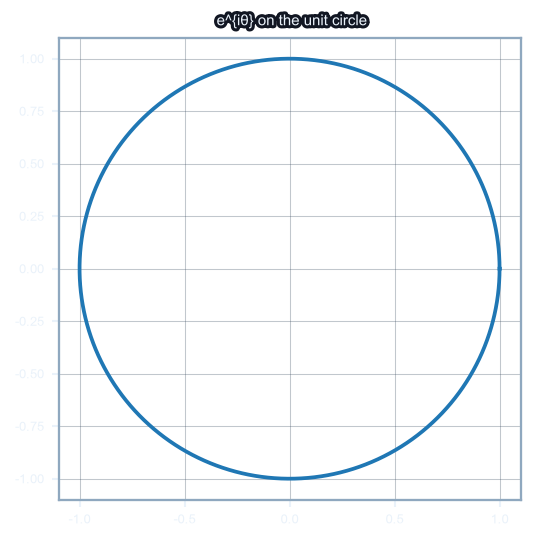

In [9]:
import numpy as np, matplotlib.pyplot as plt
fine = np.exp(1j*np.linspace(0, 2*np.pi, 200))
plt.figure(figsize=(4,4))
plt.plot(fine.real, fine.imag); plt.gca().set_aspect('equal')
plt.grid(True, alpha=.3); plt.title('e^{iθ} on the unit circle'); plt.show()

**🔗 Aurora 连接（先记一句）**：DFT = 信号与「一列 twiddle」做内积；每个频率 k 对应一列旋转因子。  
仓库里 `src/aurora/audio/transforms.py` 的 `dft()` 做的就是这件事（实现上会拼完整矩阵，与本课逐点 `twiddle(k,n,N)` 数学等价）。  
L37–L39 会把朴素 O(N²) 重写成 O(N log N) 的 FFT——**旋转因子的定义不变，变的是计算顺序**。

In [10]:
angles = np.linspace(0, 2*np.pi, 5)
for theta in angles:
    z = np.exp(1j*theta)
    reconstructed = np.cos(theta) + 1j*np.sin(theta)
    print(f'theta={theta:.2f} | exp={z:.2f} | cos+i sin={reconstructed:.2f} | match={np.allclose(z, reconstructed)}')


theta=0.00 | exp=1.00+0.00j | cos+i sin=1.00+0.00j | match=True
theta=1.57 | exp=0.00+1.00j | cos+i sin=0.00+1.00j | match=True
theta=3.14 | exp=-1.00+0.00j | cos+i sin=-1.00+0.00j | match=True
theta=4.71 | exp=-0.00-1.00j | cos+i sin=-0.00-1.00j | match=True
theta=6.28 | exp=1.00-0.00j | cos+i sin=1.00-0.00j | match=True


## 预告：为什么打印出来的角度会突然"跳"一下？

下面的参数实验会打印一串角度，前几行会规规矩矩地每次减 45°，但走到某一行，数字会突然从接近 -180° 变成 +135° 左右，看起来像是"转回去了"。**这不是 bug，也不是 twiddle 写错了**——这是 `np.angle` 这个函数本身的"读数习惯"造成的，提前说清楚，你就不会像卡在这里的同学一样，回头怀疑自己的代码。

生活比喻：家里的钟表只有 12 个刻度，指针从"11 点"继续往前走，你看到的不是"12.5 点"，而是绕回到"12 点"再到"1 点"附近——表盘的读数范围是循环的。`np.angle` 也是这样：它规定只报告 **(−180°, +180°]**（也就是 (−π, π]）范围内的读数。一个真实转到 -225° 的指针，因为 -225° 超出了这个范围，会被"折"回 +135°（-225° + 360° = 135°，方向其实还是同一个）来报告——这个现象叫"相位绕回（phase wrap）"。

`np.unwrap` 做的事就是把这种"折"回来的角度重新"抻直"：它检测相邻两个读数之间是不是有超过 180° 的假跳变，如果有，就自动加/减 360° 的整数倍，把整个序列拼回连续变化的样子。而 `np.diff` 只是"逐项相减"——算出相邻两个数字的差，本身不做任何"绕回"修正，所以一定要先 unwrap 再 diff，才能看到"每步都是 -45°"这个真实规律。

下面这段代码不依赖你的 `twiddle` 实现，直接用 `np.exp` 演示这个绕回现象，运行看看：

In [11]:
import numpy as np

# 本来连续递减的角度（模拟 twiddle 在 k=1, N=8 时该有的相位）
raw_angles = np.linspace(0, -7 * 2*np.pi/8, 8)
reported = np.angle(np.exp(1j * raw_angles))  # np.angle 只在 (-π, π] 内报告

print('本来连续递减的角度（弧度）:', np.round(raw_angles, 3))
print('np.angle 实际报告的角度:   ', np.round(reported, 3))
print()
print('不加 unwrap，直接 diff（会有一次假跳变）:', np.round(np.diff(reported), 3))
print('先 unwrap 再 diff（步长稳定在 -2π/8）  :', np.round(np.diff(np.unwrap(reported)), 3))


本来连续递减的角度（弧度）: [ 0.    -0.785 -1.571 -2.356 -3.142 -3.927 -4.712 -5.498]
np.angle 实际报告的角度:    [ 0.    -0.785 -1.571 -2.356 -3.142  2.356  1.571  0.785]

不加 unwrap，直接 diff（会有一次假跳变）: [-0.785 -0.785 -0.785 -0.785  5.498 -0.785 -0.785]
先 unwrap 再 diff（步长稳定在 -2π/8）  : [-0.785 -0.785 -0.785 -0.785 -0.785 -0.785 -0.785]


## 参数实验：观察相位均匀递减

固定 `k=1`，让 `n` 从 0 到 N-1 遍历，打印每个旋转因子的相位（`np.angle`，单位：弧度（radian）），确认相位均匀递减，步长为 `-2π/N`：

```python
N = 8
for n in range(N):
    w = twiddle(k=1, n=n, N=N)
    print(f'n={n} | angle={np.angle(w):.4f} rad ({np.degrees(np.angle(w)):.1f}°)')
# 预期：每行角度差 -45°（= -2π/8 ≈ -0.785 rad）
```

再把 N 改成 4（步长变 -90°）或 1024（步长缩到约 -0.35°），感受 N 对频率分辨率（frequency resolution）的控制。

> **提醒**：如果你已经看过上一格新插入的说明，就知道 n=5 附近会出现一次看似"不减反增"的 +135° 跳变——这是 `np.angle` 的读数范围导致的，不是 `twiddle` 写错了。
>
> **"频率分辨率"是什么意思？** N 越大，相邻两个频率刻度之间转过的角度差就越小，DFT 能够区分（分辨）出的相邻两个频率就越接近、越精细，这就是"分辨率"这个词的字面意思——就像尺子刻度越密，能量出的最小差异就越小。

In [12]:
import numpy as np

try:
    # 学习目标 #4：确认旋转因子相位均匀递减，步长为 -2π/N
    N = 8
    for n in range(N):
        w = twiddle(k=1, n=n, N=N)
        print(f'n={n} | angle={np.angle(w):.4f} rad ({np.degrees(np.angle(w)):.1f}°)')

    phases = [np.angle(twiddle(1, n, 8)) for n in range(8)]
    diffs = np.diff(np.unwrap(phases))
    assert np.allclose(diffs, -2 * np.pi / 8), '相位步长不均匀，检查 twiddle 实现'
    print(f'\n✅ 相位步长均匀，每步 {-2*np.pi/8:.4f} rad（= -2π/8）')
    print('再把 N 改成 4 或 1024，感受 N 对频率分辨率的控制。')
except (NotImplementedError, TypeError):
    print('⬜ 请先实现 twiddle(k, n, N)，再运行相位实验')


⬜ 请先实现 twiddle(k, n, N)，再运行相位实验


## 🎯 未来的回报 (Future Payoff)

今天你亲手拼出的**旋转因子 `twiddle(k, n, N)`**，会在 **L37–L39 手写 FFT / L43 STFT / L44 频谱** 再次出现——DFT 矩阵的每一行就是一串旋转因子。今天把 e^{iθ} 是"单位圆上的旋转"焊进直觉，后面重写 FFT 时才不会心虚。

## 本课收束

现在可以用 `np.exp(1j*theta)` 从任意角度算出单位圆上的复数坐标，也可以用 `twiddle(k, n, N)` 算出 DFT 的旋转因子 e^(-2πikn/N)。`twiddle` 直接对应 Aurora 音频核中 `transforms.py` 的 `dft()` 实现逻辑，L37-L39 的 FFT 实现会把它复用。下一课：**L07** 方波谐波叠加——用正弦波叠加近似方波，直观演示傅里叶级数的合成过程，建立「任何周期信号都是正弦波之和」的直觉。

`twiddle` 直接对应 `L37_dft.ipynb` 中 DFT 矩阵的构造——每一行都是一组旋转因子，与 `twiddle(k, n, N)` 数学等价。

## 白板计算前，先看一眼"负角速查表"

手算负角度的 cos、sin 最容易翻车，先花 30 秒记两条规律：

- `cos(−θ) = cos θ` —— 余弦是"偶函数"：图像左右对称，角度变负，余弦值不变。
- `sin(−θ) = −sin θ` —— 正弦是"奇函数"：角度变负，正弦值跟着变负。

生活比喻：把手表指针从 12 点位置，顺时针转 45° 和逆时针转 45°，指针的**左右位置**（横坐标，对应 cos）完全一样，但**上下位置**（纵坐标，对应 sin）恰好相反——顺时针转的那次会掉到下方（负），逆时针转的那次会翘到上方（正）。

下面直接画出白板挑战会用到的四个点（0°、-45°、-90°、-135°），标出坐标，手算完可以对照：

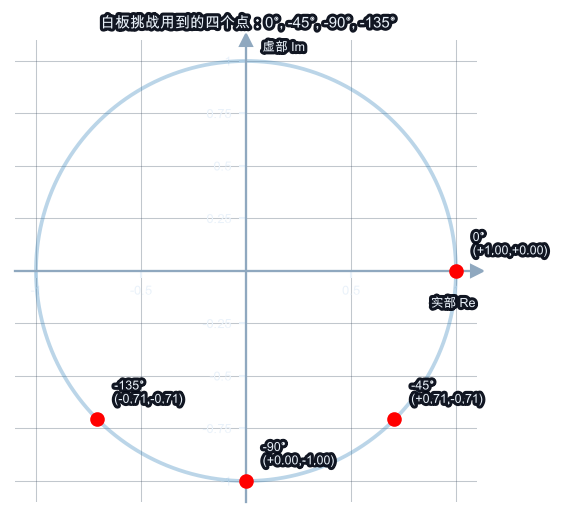

In [13]:
import numpy as np, matplotlib.pyplot as plt

angles_deg = [0, -45, -90, -135]
angles_rad = np.radians(angles_deg)
pts = np.exp(1j * angles_rad)

circle = np.exp(1j * np.linspace(0, 2*np.pi, 200))
plt.figure(figsize=(4,4))
plt.plot(circle.real, circle.imag, alpha=.3)
plt.scatter(pts.real, pts.imag, color='red', zorder=5)
for deg, p in zip(angles_deg, pts):
    plt.annotate(f'{deg}°\n({p.real:+.2f},{p.imag:+.2f})', (p.real, p.imag),
                 textcoords='offset points', xytext=(8, 8))
plt.axhline(0, color='gray', lw=.5)
plt.axvline(0, color='gray', lw=.5)
plt.gca().set_aspect('equal'); plt.grid(True, alpha=.3)
plt.title('白板挑战用到的四个点：0°, -45°, -90°, -135°')
plt.show()


## ✏️ 白板挑战：旋转因子手算（目标 8 分钟）

盖上屏幕，纸上作答：

**参数**：N = 8（8 点 DFT），k = 1，n = 0, 1, 2, 3

**问 1**：写出旋转因子公式 `W(k,n,N) = e^{-2πi·k·n/N}`，代入 k=1, N=8，化简指数部分。

**问 2**：计算 W(1, 0, 8)、W(1, 1, 8)、W(1, 2, 8)、W(1, 3, 8) 的值（极坐标或直角坐标均可）。
提示：先手算，再运行下方对答案格；需要公式提示时展开下方折叠块。

> "极坐标"写法示例：比如 W(1,1,8) 写成"模 1，角 -45°"就算极坐标写法；写成 `0.707 - 0.707j` 就是直角坐标写法，两种任选其一即可。手算负角度的 cos/sin 时，可以先回顾上面新插入的"负角速查表"和单位圆四点图。

<details><summary>卡住时可展开（先尽量不用）</summary>

W(1,n,8) = e^{-iπn/4}；n=0→1，n=1→e^{-iπ/4}=cos(-45°)+i·sin(-45°)…

n=2 → e^{-iπ/2} = cos(-90°)+i·sin(-90°)；n=3 → e^{-i3π/4} = cos(-135°)+i·sin(-135°)——符号规律见上面的"负角速查表"。

</details>

**问 3**：这 8 个旋转因子（n=0…7）均匀分布在单位圆的哪个方向？顺时针还是逆时针？

**问 4**：若 k=0，所有旋转因子 W(0,n,N) 等于多少？为什么？（下面对答案格会把这种情况称为"DC 分量"——DC 是 "Direct Current 直流" 的缩写，借到信号处理里，指"完全不随时间变化、只剩平均值"的部分；对照前面时钟的比喻，就是"转速为 0、压根不转的那根指针"。）

推导完成后运行下面格对答案。

In [14]:
try:
    # ✏️ 对答案格
    import numpy as np

    N = 8

    # 问1+问2：旋转因子手算验证
    print("Q1/Q2 ✅  W(1,n,8) = e^{-iπn/4}：")
    for n in range(4):
        w_theory = np.exp(-1j * 2 * np.pi * 1 * n / N)
        w_code   = twiddle(1, n, N)
        assert np.isclose(w_code, w_theory, atol=1e-10), f"n={n}: 不一致"
        deg = np.degrees(np.angle(w_theory))
        print(f"  n={n}: e^{{-iπ·{n}/4}} = {w_theory.real:+.4f}{w_theory.imag:+.4f}j  (相位 {deg:+.1f}°)")

    # 问3：8个旋转因子均匀分布（先 unwrap 解绕，避免 ±π 跳变污染步长）
    phases = np.unwrap([np.angle(twiddle(1, n, N)) for n in range(N)])
    diffs = np.diff(phases)
    step_deg = np.degrees(diffs[0])
    all_equal = np.allclose(diffs, diffs[0], atol=1e-10)
    assert all_equal, "相位步长不均匀"
    print(f"\nQ3 ✅  8个旋转因子均匀分布，步长 {step_deg:.1f}°（{'顺时针' if step_deg < 0 else '逆时针'}）")

    # 问4：k=0时所有因子为1
    for n in range(N):
        w0 = twiddle(0, n, N)
        assert np.isclose(w0, 1.0, atol=1e-12), f"k=0,n={n}: 期望1，得到{w0}"
    print(f"\nQ4 ✅  k=0 时 W(0,n,N) = e^0 = 1（所有时刻都不旋转 → DC分量）")
    print("\n🎉 旋转因子白板挑战通过！DFT 的核心运算已在脑中具象化。")
except (NotImplementedError, TypeError):
    print('⬜ 请先完成上面的 twiddle 练习，再运行本对答案格')

Q1/Q2 ✅  W(1,n,8) = e^{-iπn/4}：
⬜ 请先完成上面的 twiddle 练习，再运行本对答案格


In [ ]:
try:
    # ✏️ 本课自评
    l06_review = {
        "euler_formula_verified":   None,  # 验证了 e^{iθ} = cosθ+i·sinθ？True/False
        "twiddle_implemented":      None,  # twiddle(k,n,N) 实现并通过断言？True/False
        "rotation_intuition":       None,  # 理解"乘复数=旋转"？True/False
        "whiteboard_passed":        None,  # 白板挑战纸上推导完成？True/False
    }

    unfilled = [k for k, v in l06_review.items() if v is None]
    assert not unfilled, f'还未填写：{unfilled}'
    weak = [k for k, v in l06_review.items() if v is False]
    if weak:
        print(f'⚠️  需要加强：{weak}')
    else:
        print('✅ L06 全部通关！进入 L07：万物皆正弦')
except (NotImplementedError, TypeError):
    print('⬜ 请先完成上面的 TODO 练习，再运行本格')

---

→ **下一课**　[L07 · 万物皆正弦](L07_fourier_intuition.ipynb)

> 下节课将学习 **万物皆正弦**：用正弦波谐波叠加合成方波，傅里叶直觉一图彻底建立。